## Loading packages

In [1]:
import scanpy as sc 
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.metrics import adjusted_rand_score
from sklearn.decomposition import PCA

import scipy.sparse as sp 
import warnings

warnings.filterwarnings("ignore")

import os
import ctypes
import sys

# 1. 先设置 R_HOME
os.environ["R_HOME"] = "/home/pxy/miniconda3/envs/r40/lib/R"

# 2. 【核心黑科技】手动加载 R 的动态库
# 这步操作等同于在终端里设置 LD_LIBRARY_PATH，专门解决 VS Code 找不到库的问题
try:
    # 这是 R 的核心库路径
    libR_path = "/home/pxy/miniconda3/envs/r40/lib/R/lib/libR.so"
    # 强制加载进内存
    ctypes.CDLL(libR_path, mode=ctypes.RTLD_GLOBAL)
    print("✅ 成功强制加载 libR.so")
except OSError as e:
    print(f"❌ 加载失败: {e}")

# 3. 然后再导入其他包
sys.path.append("..") 

import spCLUE
import rpy2.robjects as robjects
print("R 环境路径:", robjects.r['R.home']()[0])

spCLUE.fix_seed(0)

✅ 成功强制加载 libR.so
R 环境路径: /home/pxy/miniconda3/envs/r40/lib/R


## Loading data

In [2]:
sample_name="151671"
n_clusters = 5 if sample_name in [str(151669 + x) for x in range(4)] else 7
data_dir  = '/home/pxy/home/pxy/data/DLPFC/st/'

# data_file = f"../dataset/DLPFC/{sample_name}.h5ad"
# adata = sc.read_h5ad(data_file)
adata = sc.read_visium(data_dir + sample_name)
adata.var_names_make_unique()
print(adata)

AnnData object with n_obs × n_vars = 4110 × 33538
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'


In [3]:
import pandas as pd

meta = pd.read_csv(
    data_dir+sample_name+"/metadata.tsv",
    sep="\t"
)

meta = meta.set_index("barcode")
adata.obs["Region"] = meta.loc[
    adata.obs_names,
    "layer_guess_reordered"
]
print(adata.obs["Region"].value_counts())
print("NA spots:", adata.obs["Region"].isna().sum())


Region
Layer3    1918
Layer6     760
Layer5     721
WM         449
Layer4     245
Name: count, dtype: int64
NA spots: 17


In [4]:
# adata = spCLUE.preprocess(adata)
# adata.obsm["X_pca"] = PCA(n_components=200, random_state=0).fit_transform(adata.X)
# g_spatia = spCLUE.prepare_graph(adata, "spatial")
# g_expr = spCLUE.prepare_graph(adata, "expr")
# graph_dict = {"spatial": g_spatia, "expr":g_expr}

In [5]:
# from spCLUE.preprocess import prepare_raw_counts_for_reconstruction
adata =spCLUE.preprocess(adata,n_top_genes=3000)
adata.obsm["X_pca"] = PCA(n_components=200, random_state=0).fit_transform(adata.X)
g_spatia = spCLUE.prepare_graph(adata, "spatial",n_neighbors=8)
g_expr = spCLUE.prepare_graph(adata, "expr",n_neighbors=8)
graph_dict = {"spatial": g_spatia, "expr":g_expr}


预处理单切片数据 (全基因 PCA + 归一化 HVG)

根据原始计数挑选 top 3000 个高变基因...
全量数据归一化 (target_sum=1e4) & Log1p...
  ✓ 已保存归一化后的 HVG 重构目标: (4110, 3000)
将全量稀疏矩阵转换为稠密矩阵以计算 PCA...
计算 PCA (基于全基因归一化数据, n_components=200)...

✅ 预处理完成！
  - adata.X (全量归一化): (4110, 12811)
  - adata.obsm['X_hvg'] (归一化HVG): (4110, 3000)
  - adata.obsm['X_pca'] (全基因PCA): (4110, 200)

构建 spatial 图...
  - 使用空间坐标: (4110, 2)
  ✓ 空间图构建完成:  (4110, 4110), 边数=35100

构建 expr 图...
  - 使用PCA:  (4110, 200)
  ✓ 表达图构建完成: (4110, 4110), 边数=64732


## train spCLUE

In [6]:
spCLUE_model = spCLUE.spCLUE(
    input_data=adata.obsm['X_pca'],
    hvg_input=adata.obsm['X_pca'],
    graph_dict=graph_dict,
    n_clusters=7,
    reconstruction_loss='mse',
    gamma=1.0,
    gamma_mask=0.5,
    beta=1.0,
    kappa=5.0,
    # cluster_weight_strategy='min',  # 🔥 置信度策略
    # cluster_warmup_epochs=50,       # 🔥 Warmup
    # dim_input=2000,
    # dim_hidden=256,
    dim_embed=16,
    graph_corr=0.4,
    epochs = 800,
    patience=50,
    min_delta=0.005,
)
_, adata.obsm["spCLUE"] = spCLUE_model.train()

ℹ️ 初始化单切片模型 (CCGCN)
   - 输入:  200维PCA
   - 重构: 2000个HVG
✅ 使用 MSE 重构损失
Training Start =========================>
重构损失类型: MSE
聚类对齐策略: min
Warmup epochs: 50
早停策略: patience=50, min_delta=0.005
损失权重: kappa=5.0, beta=1.0, gamma=1.0


  1%|          | 5/800 [00:01<02:34,  5.16it/s]


Epoch 1:   Loss=13.0330, ARI=0.037
 Cluster=2.5710, Recon=2.2871, MaskRecon=2.2906, LocalAgg=0.7030
  ClusterLoss=2.5627, NegLoss=0.0083


  7%|▋         | 57/800 [00:02<00:21, 34.96it/s]


Epoch 50:   Loss=11.6058, ARI=0.419
 Cluster=2.3849, Recon=2.2677, MaskRecon=2.2300, LocalAgg=0.5838
  ClusterLoss=2.3840, NegLoss=0.0009


...


Epoch 300:   Loss=9.5731, ARI=0.459
 Cluster=0.6631, Recon=2.2376, MaskRecon=2.2130, LocalAgg=0.5566
  ClusterLoss=0.6485, NegLoss=0.0147


 45%|████▍     | 357/800 [00:10<00:12, 36.34it/s]


Epoch 350:   Loss=9.3156, ARI=0.493
 Cluster=0.5740, Recon=2.2355, MaskRecon=2.2387, LocalAgg=0.5387
  ClusterLoss=0.5596, NegLoss=0.0143


 48%|████▊     | 384/800 [00:11<00:12, 32.79it/s]


Early stopping at epoch 385
Best loss: 9.2318
Training Finished =================<


In [7]:
print(adata.obsm["spCLUE"].shape)


(4110, 32)


In [8]:
refinement = True
cluster_method = "mclust"
pred = spCLUE.clustering(
    adata,
    n_clusters,
    key="spCLUE",
    refinement=refinement,
    cluster_methods=cluster_method,
)

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.2
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


In [9]:
print(adata.obs.columns)

Index(['in_tissue', 'array_row', 'array_col', 'Region', 'mclust',
       'mclust_refined'],
      dtype='object')


In [10]:
adata = adata[adata.obs.Region.notna()]
ARI = adjusted_rand_score(adata.obs["Region"], adata.obs["mclust_refined"])
print(f"ARI on {sample_name}: {ARI}")

ARI on 151671: 0.6504459996826597


## visualization

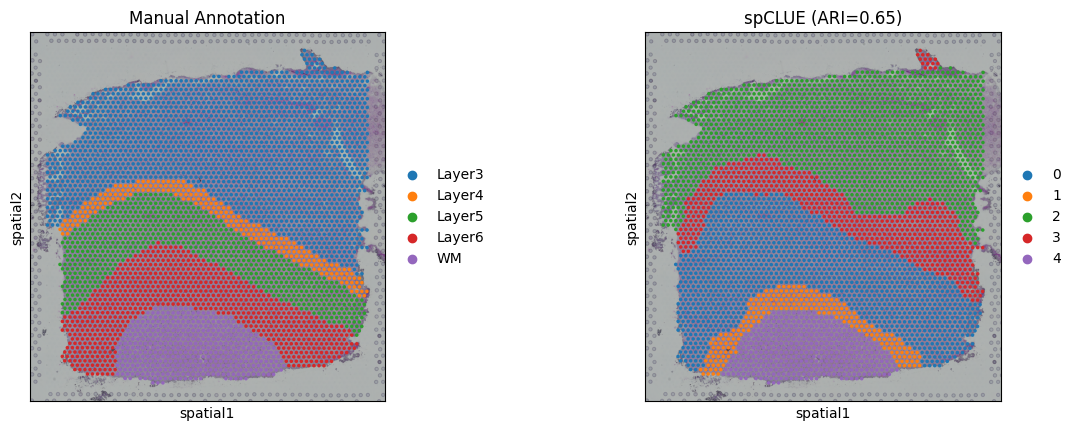

In [11]:
adata.obs["spCLUE"] = adata.obs["mclust_refined"]
sc.pl.spatial(adata, color=["Region", "spCLUE"], title=["Manual Annotation", f"spCLUE (ARI={round(ARI, 2)})"])

In [12]:
# # 1. 计算邻居图（如果尚未计算）
# # 如果已计算过可跳过此步
# sc.pp.neighbors(adata, use_rep="spCLUE", metric="cosine")

# # 2. 计算UMAP嵌入
# sc.tl.umap(adata)

# # 3. 可视化UMAP，按spCLUE聚类结果着色
# sc.pl.umap(
#     adata,
#     color=["spCLUE", "Region"],  # 同时显示聚类结果和手动注释进行对比
#     title=["spCLUE Clusters", "Manual Annotation"],
#     frameon=False,
#     wspace=0.6,  # 调整子图间距
#     legend_loc="on data",
#     # save="spCLUE_umap.pdf"  # 可选：自动保存图像
# )

# # 4. （可选）显示聚类簇编号在图上
# # sc.pl.umap(
# #     adata,
# #     color="spCLUE",
# #     title=f"spCLUE UMAP (ARI={round(ARI, 2)})",
# #     legend_loc="on data",
# #     add_outline=True,
# #     outline_width=0.01
# # )